In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [6]:
df = pd.read_csv('dataset.csv')

In [7]:
df.head()

,loan_id,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
0,lp001002,male,no,0,graduate,no,5849,0.0,NaN,360.0,1.0,urban,y
1,lp001003,male,yes,1,graduate,no,4583,1508.0,128.0,360.0,1.0,rural,n
2,lp001005,male,yes,0,graduate,yes,3000,0.0,66.0,360.0,1.0,urban,y
3,lp001006,male,yes,0,not graduate,no,2583,2358.0,120.0,360.0,1.0,urban,y
4,lp001008,male,no,0,graduate,no,6000,0.0,141.0,360.0,1.0,urban,y


In [8]:
df.describe()

,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   loan_id            614 non-null    object 
 1   gender             601 non-null    object 
 2   married            611 non-null    object 
 3   dependents         599 non-null    object 
 4   education          614 non-null    object 
 5   self_employed      582 non-null    object 
 6   applicantincome    614 non-null    int64  
 7   coapplicantincome  614 non-null    float64
 8   loanamount         592 non-null    float64
 9   loan_amount_term   600 non-null    float64
 10  credit_history     564 non-null    float64
 11  property_area      614 non-null    object 
 12  loan_status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isnull().sum()

,0
loan_id,0
gender,13
married,3
dependents,15
education,0
self_employed,32
applicantincome,0
coapplicantincome,0
loanamount,22
loan_amount_term,14


In [12]:
df.head()

,loan_id,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
0,lp001002,male,no,0,graduate,no,5849,0.0,NaN,360.0,1.0,urban,y
1,lp001003,male,yes,1,graduate,no,4583,1508.0,128.0,360.0,1.0,rural,n
2,lp001005,male,yes,0,graduate,yes,3000,0.0,66.0,360.0,1.0,urban,y
3,lp001006,male,yes,0,not graduate,no,2583,2358.0,120.0,360.0,1.0,urban,y
4,lp001008,male,no,0,graduate,no,6000,0.0,141.0,360.0,1.0,urban,y


In [13]:
cat_log = ['gender', 'married', 'self_employed']

for col in cat_log:
    df[col] = df[col].fillna(df[col].mode()[0])

In [14]:
df.isnull().sum()

,0
loan_id,0
gender,0
married,0
dependents,15
education,0
self_employed,0
applicantincome,0
coapplicantincome,0
loanamount,22
loan_amount_term,14


In [15]:
df['dependents']

,dependents
0,0
1,1
2,0
3,0
4,0
...,...
609,0
610,3+
611,1
612,2


In [16]:
df['dependents']= df['dependents'].replace('3+','3')

In [17]:
df['dependents'] = df['dependents'].fillna('0').astype(int)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   loan_id            614 non-null    object 
 1   gender             614 non-null    object 
 2   married            614 non-null    object 
 3   dependents         614 non-null    int64  
 4   education          614 non-null    object 
 5   self_employed      614 non-null    object 
 6   applicantincome    614 non-null    int64  
 7   coapplicantincome  614 non-null    float64
 8   loanamount         592 non-null    float64
 9   loan_amount_term   600 non-null    float64
 10  credit_history     564 non-null    float64
 11  property_area      614 non-null    object 
 12  loan_status        614 non-null    object 
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ KB


In [19]:
num_col = ['loanamount','loan_amount_term','credit_history']
for col in num_col:
  df[col] = df[col].fillna(df[col].median())

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   loan_id            614 non-null    object 
 1   gender             614 non-null    object 
 2   married            614 non-null    object 
 3   dependents         614 non-null    int64  
 4   education          614 non-null    object 
 5   self_employed      614 non-null    object 
 6   applicantincome    614 non-null    int64  
 7   coapplicantincome  614 non-null    float64
 8   loanamount         614 non-null    float64
 9   loan_amount_term   614 non-null    float64
 10  credit_history     614 non-null    float64
 11  property_area      614 non-null    object 
 12  loan_status        614 non-null    object 
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ KB


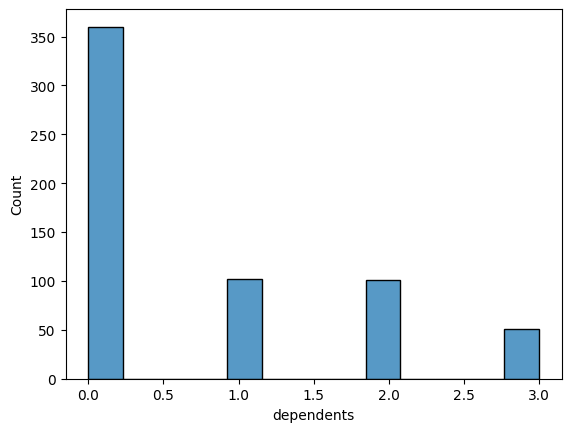

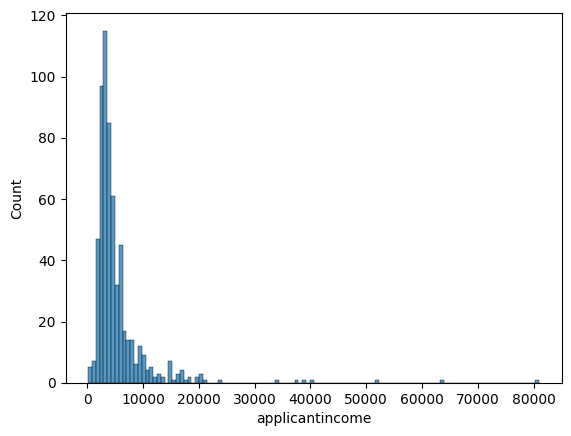

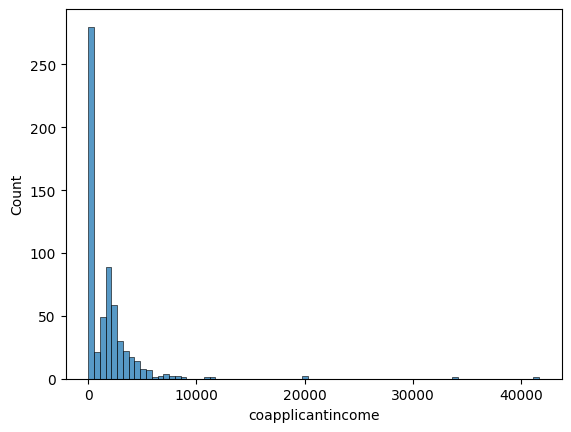

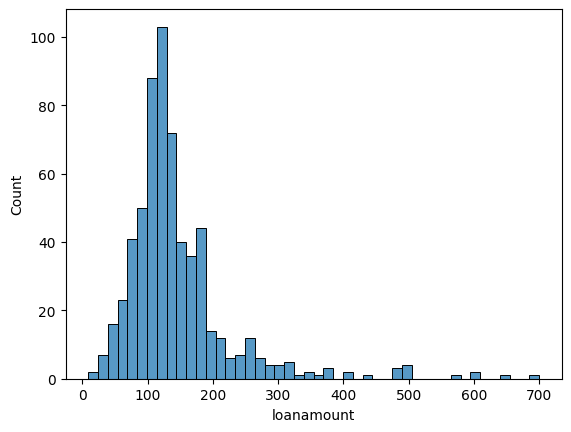

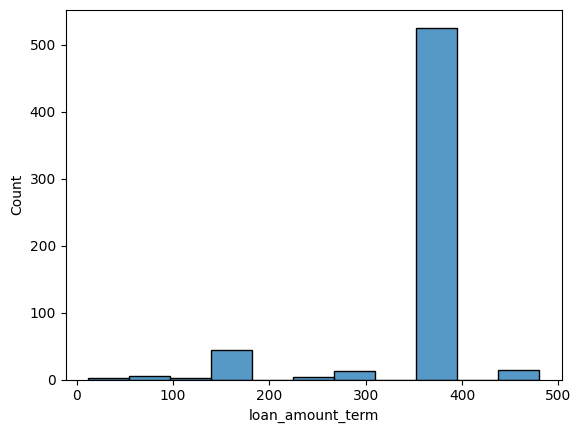

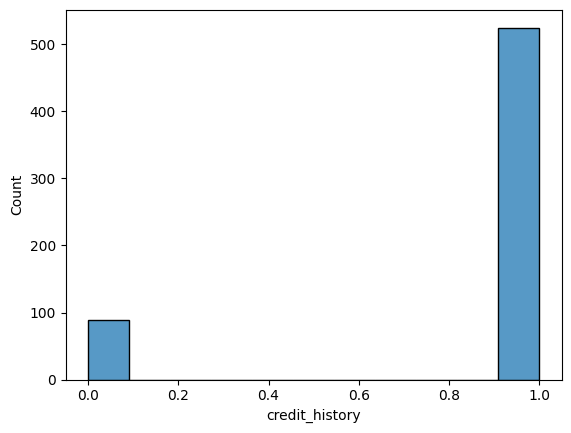

In [21]:
for col in df.columns:
    if df[col].dtype == 'float64' or df[col].dtype == 'int64':
        sns.histplot(x=df[col])
        plt.show()

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   loan_id            614 non-null    object 
 1   gender             614 non-null    object 
 2   married            614 non-null    object 
 3   dependents         614 non-null    int64  
 4   education          614 non-null    object 
 5   self_employed      614 non-null    object 
 6   applicantincome    614 non-null    int64  
 7   coapplicantincome  614 non-null    float64
 8   loanamount         614 non-null    float64
 9   loan_amount_term   614 non-null    float64
 10  credit_history     614 non-null    float64
 11  property_area      614 non-null    object 
 12  loan_status        614 non-null    object 
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ KB


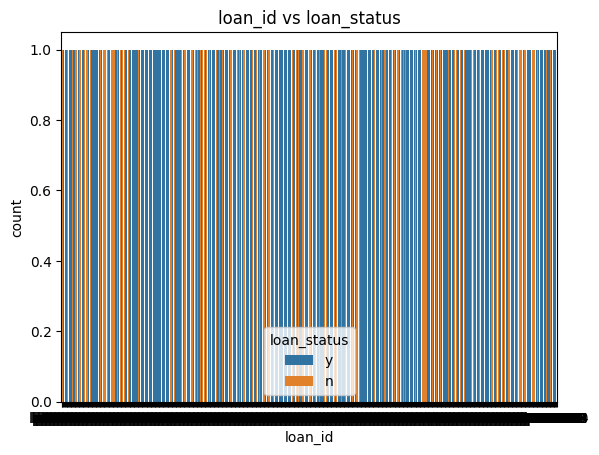

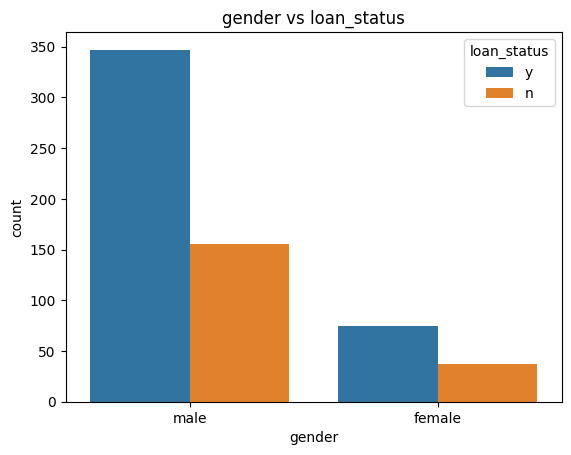

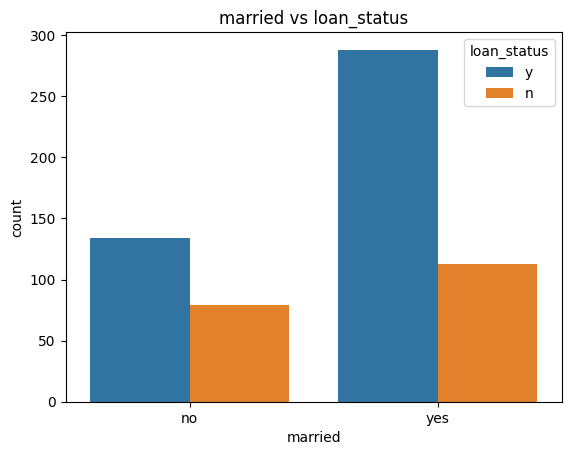

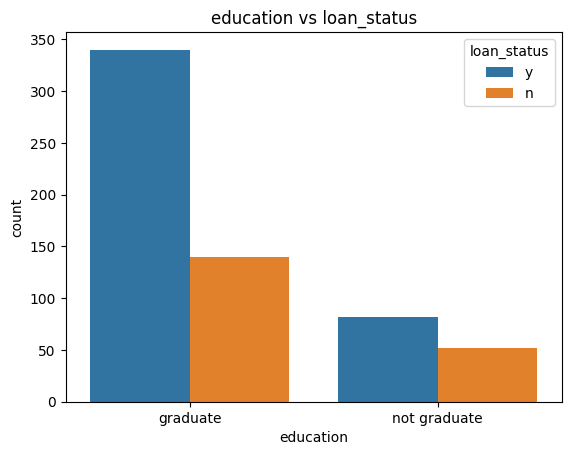

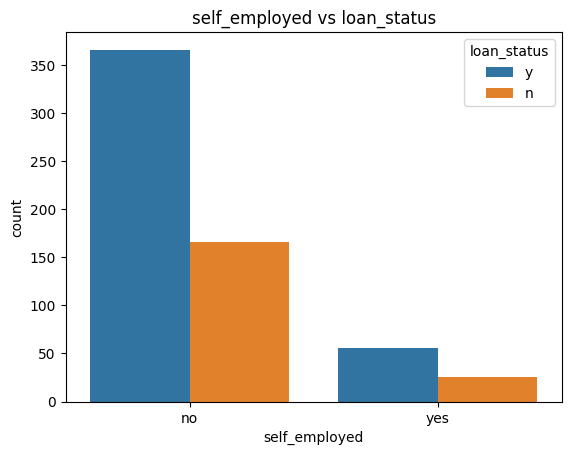

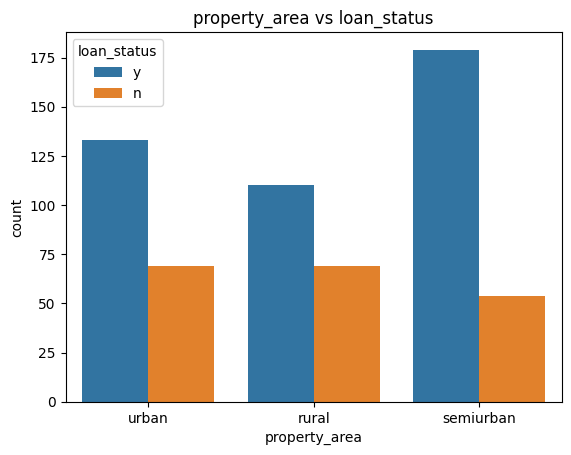

In [23]:
target = 'loan_status'
for col in df.columns:
    if df[col].dtype == 'object' and col != target:
        sns.countplot(x=df[col], hue=df[target])
        plt.title(f'{col} vs {target}')
        plt.show()

In [24]:
df.columns

Index(['loan_id', 'gender', 'married', 'dependents', 'education',
       'self_employed', 'applicantincome', 'coapplicantincome', 'loanamount',
       'loan_amount_term', 'credit_history', 'property_area', 'loan_status'],
      dtype='object')

In [25]:
df['gender'].nunique()

2

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in df.columns:
    if df[col].nunique() == 2 and df[col].dtype == "object":
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

In [27]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False)
cat_cols= ['property_area']
encoded = ohe.fit_transform(df[cat_cols])
encoded_df = pd.DataFrame(
    encoded,
    columns = ohe.get_feature_names_out(cat_cols),
    index = df.index
)

df = pd.concat(
    [df.drop(cat_cols,axis=1),encoded_df],
    axis=1
)


In [28]:
df.head()

,loan_id,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,loan_status,property_area_rural,property_area_semiurban,property_area_urban
0,lp001002,1,0,0,0,0,5849,0.0,128.0,360.0,1,1,0.0,0.0,1.0
1,lp001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1,0,1.0,0.0,0.0
2,lp001005,1,1,0,0,1,3000,0.0,66.0,360.0,1,1,0.0,0.0,1.0
3,lp001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1,1,0.0,0.0,1.0
4,lp001008,1,0,0,0,0,6000,0.0,141.0,360.0,1,1,0.0,0.0,1.0


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   loan_id                  614 non-null    object 
 1   gender                   614 non-null    int64  
 2   married                  614 non-null    int64  
 3   dependents               614 non-null    int64  
 4   education                614 non-null    int64  
 5   self_employed            614 non-null    int64  
 6   applicantincome          614 non-null    int64  
 7   coapplicantincome        614 non-null    float64
 8   loanamount               614 non-null    float64
 9   loan_amount_term         614 non-null    float64
 10  credit_history           614 non-null    int64  
 11  loan_status              614 non-null    int64  
 12  property_area_rural      614 non-null    float64
 13  property_area_semiurban  614 non-null    float64
 14  property_area_urban      6

In [30]:
X = df.drop(['loan_status', 'loan_id'], axis=1)
y = df['loan_status']

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

**RandomForestClassifier**

In [32]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier()

rfc.fit(X_train,y_train)

RandomForestClassifier()

In [33]:
y_pred_rfc = rfc.predict(X_test)

In [34]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
acc_rfc= accuracy_score(y_test,y_pred_rfc)
f1_rfc = f1_score(y_test,y_pred_rfc)
roc_rfc = roc_auc_score(y_test, y_pred_rfc)
acc_rfc,f1_rfc,acc_rfc

(0.7881773399014779, 0.8512110726643599, 0.7881773399014779)

In [35]:
from sklearn.linear_model import LogisticRegression
lg = LogisticRegression()
lg.fit(X_train,y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [36]:
y_pred_lg = lg.predict(X_test)

In [37]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
acc_lg = accuracy_score(y_test,y_pred_lg)
f1_lg = f1_score(y_test,y_pred_lg)
roc_lg = roc_auc_score(y_test,y_pred_lg)
acc_lg,f1_lg,roc_lg

(0.7635467980295566, 0.8441558441558441, np.float64(0.6697943172179814))

**SVM**

In [38]:
from sklearn.svm import SVC
svm = SVC()
svm.fit(X_train,y_train)

SVC()

In [39]:
y_pred_svm = svm.predict(X_test)

In [40]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
acc_svm = accuracy_score(y_test,y_pred_svm)
f1_svm = f1_score(y_test,y_pred_svm)
roc_svm = roc_auc_score(y_test,y_pred_svm)
acc_svm,f1_svm,roc_svm

(0.645320197044335, 0.7844311377245509, np.float64(0.5))

In [41]:
from sklearn.ensemble import GradientBoostingClassifier
gbc = GradientBoostingClassifier()
gbc.fit(X_train,y_train)

GradientBoostingClassifier()

In [42]:
y_pred_gbc = gbc.predict(X_test)

In [43]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
acc_gbc = accuracy_score(y_test,y_pred_gbc)
f1_gbc = f1_score(y_test,y_pred_gbc)
roc_gbc = roc_auc_score(y_test,y_pred_gbc)
acc_gbc,f1_gbc,roc_gbc

(0.7684729064039408, 0.8406779661016949, np.float64(0.6955046649703138))

In [44]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [45]:
y_pred_xgb = xgb.predict(X_test)

In [46]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
acc_xgb = accuracy_score(y_test,y_pred_xgb)
f1_score_xgb = f1_score(y_test,y_pred_xgb)
roc_score_xgb = roc_auc_score(y_test,y_pred_xgb)
acc_xgb,f1_score_xgb,roc_score_xgb

(0.7733990147783252, 0.8357142857142857, np.float64(0.724342663273961))

**Hyperperameter in Random Forest**

In [63]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state = 42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs= -1
)
grid.fit(X_train,y_train)
grid.best_params_,grid.best_score_


({'max_depth': 5,
  'min_samples_leaf': 2,
  'min_samples_split': 5,
  'n_estimators': 100},
 np.float64(0.8827853804571053))

In [64]:
best_rfc = grid.best_estimator_
y_pred_best_rfc = best_rfc.predict(X_test)

In [65]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score,recall_score
acc_best_rfc = accuracy_score(y_test,y_pred_best_rfc)
f1_best_rfc = f1_score(y_test,y_pred_best_rfc)
y_prob_best_rfc = best_rfc.predict_proba(X_test)[:, 1]
roc_best_rfc = roc_auc_score(y_test,y_prob_best_rfc)
recall_best_rfc = recall_score(y_test,y_pred_best_rfc)
acc_best_rfc,f1_best_rfc,roc_best_rfc,recall_best_rfc

(0.7980295566502463,
 0.862876254180602,
 np.float64(0.7841391009329941),
 0.9847328244274809)

In [66]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_best_rfc))
print(classification_report(y_test, y_pred_best_rfc))

[[ 33  39]
 [  2 129]]
              precision    recall  f1-score   support

           0       0.94      0.46      0.62        72
           1       0.77      0.98      0.86       131

    accuracy                           0.80       203
   macro avg       0.86      0.72      0.74       203
weighted avg       0.83      0.80      0.78       203



In [51]:
importance = pd.Series(
    best_rfc.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

In [52]:
importance

,0
credit_history,0.222531
applicantincome,0.187264
loanamount,0.167751
coapplicantincome,0.116771
dependents,0.056463
loan_amount_term,0.055849
property_area_semiurban,0.045130
married,0.032566
gender,0.025176
property_area_rural,0.024061


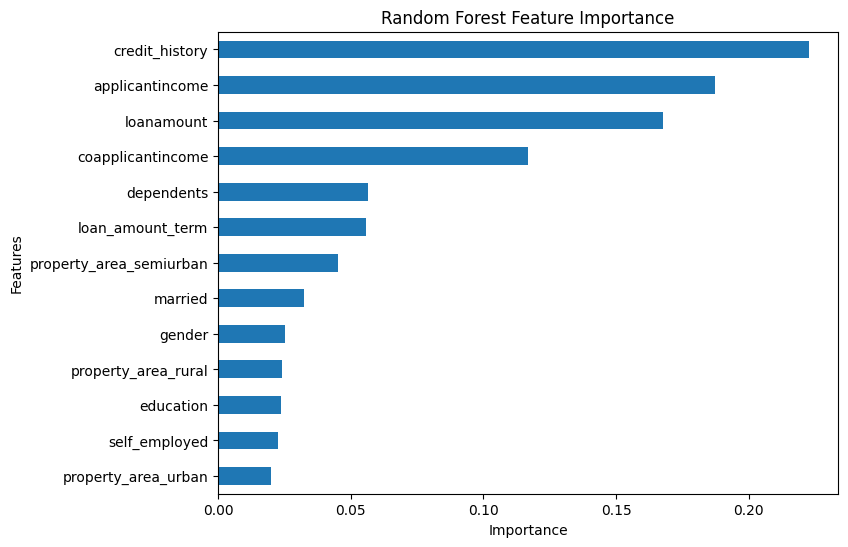

In [53]:
importance.sort_values().plot(kind='barh', figsize=(8, 6))

plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Random Forest Feature Importance')

plt.show()